In [10]:
!pip install google-play-scraper

import pandas as pd
from google_play_scraper import Sort, reviews

app_id = 'id.go.imigrasi.paspor_online'

result, continuation_token = reviews(
    app_id,
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=200
)

df_gplay = pd.DataFrame(result)

df_gplay = df_gplay[['content', 'score', 'at']]
df_gplay.columns = ['content', 'score', 'date']

df_gplay.head()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.6 MB/s eta 0:00:00


,content,score,date
0,setiap kantor imigrasi pelayanannya beda2. per...,3,2026-04-16 09:15:58
1,"menyulitkan. email udah bener, tapi kode OTP n...",5,2026-04-16 00:49:59
2,sangat membantu memudahkan proses pembuatan pa...,5,2026-04-15 22:19:20
3,Keren,5,2026-04-15 14:19:34
4,layanan bagus,5,2026-04-15 07:29:33


### Informasi Dataset

In [11]:
print('Informasi Umum DataFrame:')
df_gplay.info()

print('\nStatistik Deskriptif DataFrame:')
display(df_gplay.describe(include='all'))

Informasi Umum DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   content  200 non-null    object        
 1   score    200 non-null    int64         
 2   date     200 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 4.8+ KB

Statistik Deskriptif DataFrame:


,content,score,date
count,200,200.000000,200
unique,195,NaN,NaN
top,ok,NaN,NaN
freq,3,NaN,NaN
mean,NaN,2.215000,2026-03-25 14:01:38.025000192
min,NaN,1.000000,2026-02-20 08:29:44
25%,NaN,1.000000,2026-03-16 18:37:15.249999872
50%,NaN,1.000000,2026-03-28 18:49:11.500000
75%,NaN,3.250000,2026-04-06 12:55:02.500000
max,NaN,5.000000,2026-04-16 09:15:58


In [12]:
def label_sentimen(score):
    if score >= 4:
        return "positif"
    elif score == 3:
        return "netral"
    else:
        return "negatif"

df_gplay['label'] = df_gplay['score'].apply(label_sentimen)

display(df_gplay.head())

,content,score,date,label
0,setiap kantor imigrasi pelayanannya beda2. per...,3,2026-04-16 09:15:58,netral
1,"menyulitkan. email udah bener, tapi kode OTP n...",5,2026-04-16 00:49:59,positif
2,sangat membantu memudahkan proses pembuatan pa...,5,2026-04-15 22:19:20,positif
3,Keren,5,2026-04-15 14:19:34,positif
4,layanan bagus,5,2026-04-15 07:29:33,positif


### 2️⃣ Preprocessing teks

In [25]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df_gplay['clean_text'] = df_gplay['content'].apply(clean_text)

display(df_gplay.head())

,content,score,date,label,clean_text
0,setiap kantor imigrasi pelayanannya beda2. per...,3,2026-04-16 09:15:58,netral,setiap kantor imigrasi pelayanannya beda perta...
1,"menyulitkan. email udah bener, tapi kode OTP n...",5,2026-04-16 00:49:59,positif,menyulitkan email udah bener tapi kode otp nda...
2,sangat membantu memudahkan proses pembuatan pa...,5,2026-04-15 22:19:20,positif,sangat membantu memudahkan proses pembuatan pa...
3,Keren,5,2026-04-15 14:19:34,positif,keren
4,layanan bagus,5,2026-04-15 07:29:33,positif,layanan bagus


### 3️⃣ TF-IDF

In [29]:
!pip install PySastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 6.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kurangnya', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Buat final_stopwords
factory = StopWordRemoverFactory()
sastrawi_stopwords = set(factory.get_stop_words())

custom_stopwords = set()
final_stopwords = sastrawi_stopwords.union(custom_stopwords)

# TF-IDF dengan stopwords
tfidf = TfidfVectorizer(
    max_features=100,
    stop_words=list(final_stopwords)
)
X = tfidf.fit_transform(df_gplay['clean_text'])
y = df_gplay['label']

### 4️⃣ Split data

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 5️⃣ Model (Naive Bayes)

In [19]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

### 6️⃣ Evaluasi

In [32]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7
              precision    recall  f1-score   support

     negatif       0.68      1.00      0.81        23
      netral       0.00      0.00      0.00         4
     positif       0.83      0.38      0.53        13

    accuracy                           0.70        40
   macro avg       0.50      0.46      0.44        40
weighted avg       0.66      0.70      0.64        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 7️⃣ Visualisasi

/tmp/ipykernel_35171/2354431373.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_gplay, palette='viridis')


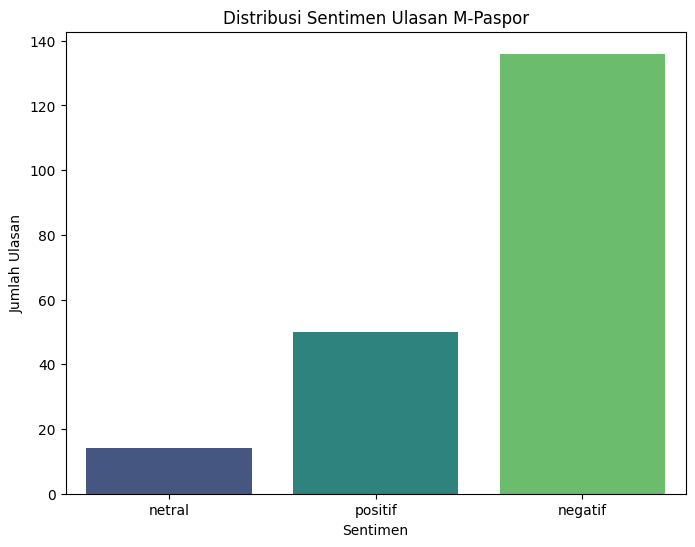

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar chart for sentiment distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df_gplay, palette='viridis')
plt.title('Distribusi Sentimen Ulasan M-Paspor')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.show()

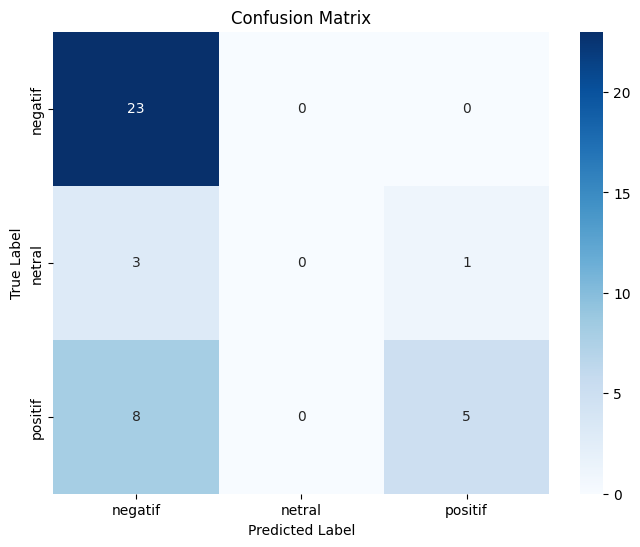

In [23]:
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Word Cloud Berdasarkan Sentimen

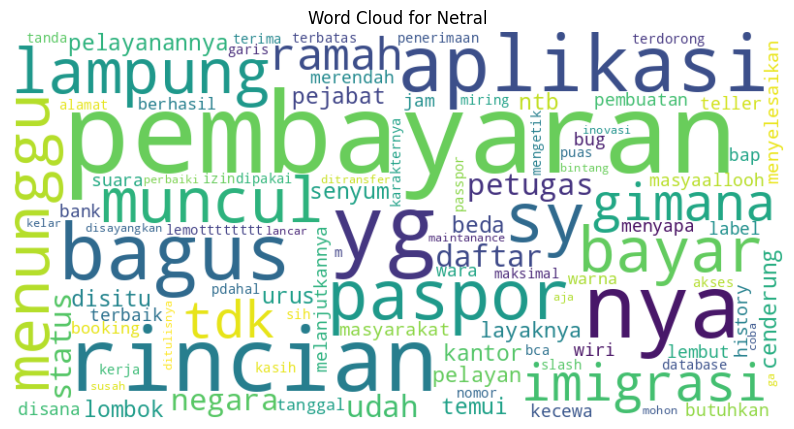

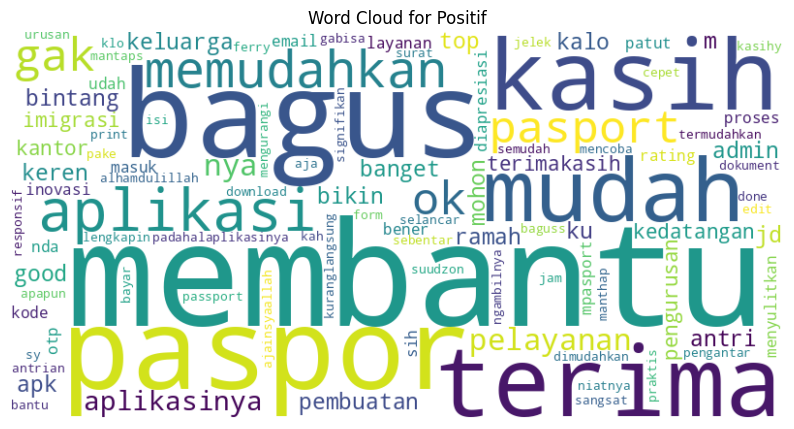

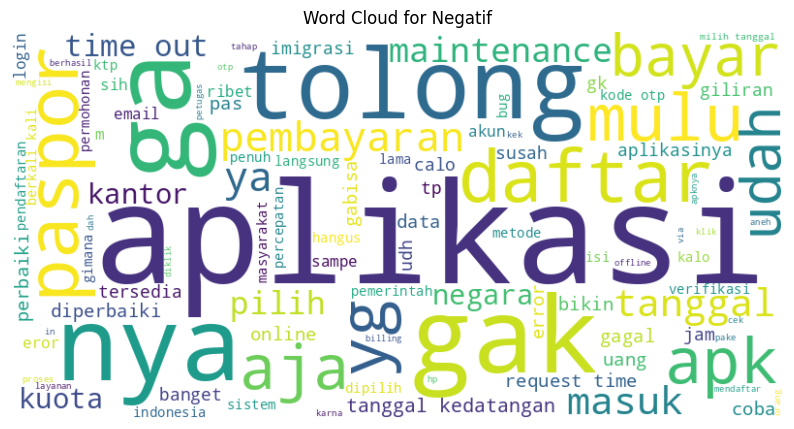

In [27]:
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

try:
    stopwords.words('indonesian')
except LookupError:
    nltk.download('stopwords')

stop_words_indo = set(stopwords.words('indonesian'))

custom_stopwords = []
final_stopwords = stop_words_indo.union(custom_stopwords)

sentiments = df_gplay['label'].unique()

# Define specific keywords for clarity
negative_keywords = ['error', 'gagal', 'ribet', 'eror', 'perbaiki', 'aneh', 'bug', 'mempersulit', 'masalah', 'lama', 'kecewa']
positive_keywords = ['berguna', 'memudahkan']

for sentiment in sentiments:
    text_sentiment = ' '.join(df_gplay[df_gplay['label'] == sentiment]['clean_text'])

    current_stopwords = set(final_stopwords)

    if sentiment == 'positif':
        current_stopwords.update(negative_keywords)
        current_stopwords.difference_update(positive_keywords)

    elif sentiment == 'negatif':
        current_stopwords.update(positive_keywords)
        current_stopwords.difference_update(negative_keywords)

    elif sentiment == 'netral':
        neutral_specific_stopwords = [
            'halaman', 'beranda', 'perjalan', 'kuning', 'kanim', 'hijau', 'pp', 'bilang',
            'menggunakan', 'karena', 'cirebon', 'tab', 'sia', 'batal',
            'bro', 'minggu', 'kan', 'spasi', 'menempuh', 'pengisian', 'sebelumnya', 'ulang', 'transaksi',
            'pajak', 'rumah', 'tambah', 'jumlah', 'merah', 'bbrp', 'aplikasinya', 'perjalanan', 'sat',
            'oleh', 'berwarna', 'karakternya skrg'
        ]
        current_stopwords.update(neutral_specific_stopwords)


    wordcloud_sentiment = WordCloud(
        width=800, height=400, background_color='white',
        stopwords=current_stopwords, max_words=100
    ).generate(text_sentiment)

    plt.figure(figsize=(10, 7))
    plt.imshow(wordcloud_sentiment, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for {sentiment.capitalize()}')
    plt.show()

In [ ]:
df_gplay.to_csv('m-paspor_google_play_reviews.csv', index=False)
print('File saved as m-paspor_google_play_reviews.csv')

In [ ]:
from google.colab import files
files.download('m-paspor_google_play_reviews.csv')